In [3]:
import pandas as pd

In [4]:
data = pd.read_csv('../Divvy_2024_All_Months_Combined.csv')

In [10]:
# data.drop(columns=['Unnamed: 0'], inplace=True)
print( data.head())

            ride_id  rideable_type  rideable_type_code           started_at  \
0  597F4161CCE5A7C9   classic_bike                 0.0  2024-04-09 10:19:14   
1  E0EDA091FC69402A   classic_bike                 0.0  2024-04-06 22:23:31   
2  C384D6B5AF4E869A   classic_bike                 0.0  2024-04-11 18:05:06   
3  D920556786E473B5   classic_bike                 0.0  2024-04-22 05:50:03   
4  ED290370BA829535  electric_bike                 1.0  2024-04-05 19:10:53   

              ended_at  ride_length month_name day_of_week hour_of_day  \
0  2024-04-09 10:22:02     2.800000      April     Tuesday       10 AM   
1  2024-04-06 22:30:03     6.533333      April    Saturday       10 PM   
2  2024-04-11 18:11:20     6.233333      April    Thursday       06 PM   
3  2024-04-22 05:53:05     3.033333      April      Monday       05 AM   
4  2024-04-05 19:21:53    11.000000      April      Friday       07 PM   

         start_station_name start_station_id  start_lat  start_lng  \
0       El

Dataset Shape: (12622478, 19)

First Few Rows:
            ride_id  rideable_type  rideable_type_code           started_at  \
0  597F4161CCE5A7C9   classic_bike                 0.0  2024-04-09 10:19:14   
1  E0EDA091FC69402A   classic_bike                 0.0  2024-04-06 22:23:31   
2  C384D6B5AF4E869A   classic_bike                 0.0  2024-04-11 18:05:06   
3  D920556786E473B5   classic_bike                 0.0  2024-04-22 05:50:03   
4  ED290370BA829535  electric_bike                 1.0  2024-04-05 19:10:53   

              ended_at  ride_length month_name day_of_week hour_of_day  \
0  2024-04-09 10:22:02     2.800000      April     Tuesday       10 AM   
1  2024-04-06 22:30:03     6.533333      April    Saturday       10 PM   
2  2024-04-11 18:11:20     6.233333      April    Thursday       06 PM   
3  2024-04-22 05:53:05     3.033333      April      Monday       05 AM   
4  2024-04-05 19:21:53    11.000000      April      Friday       07 PM   

         start_station_name start

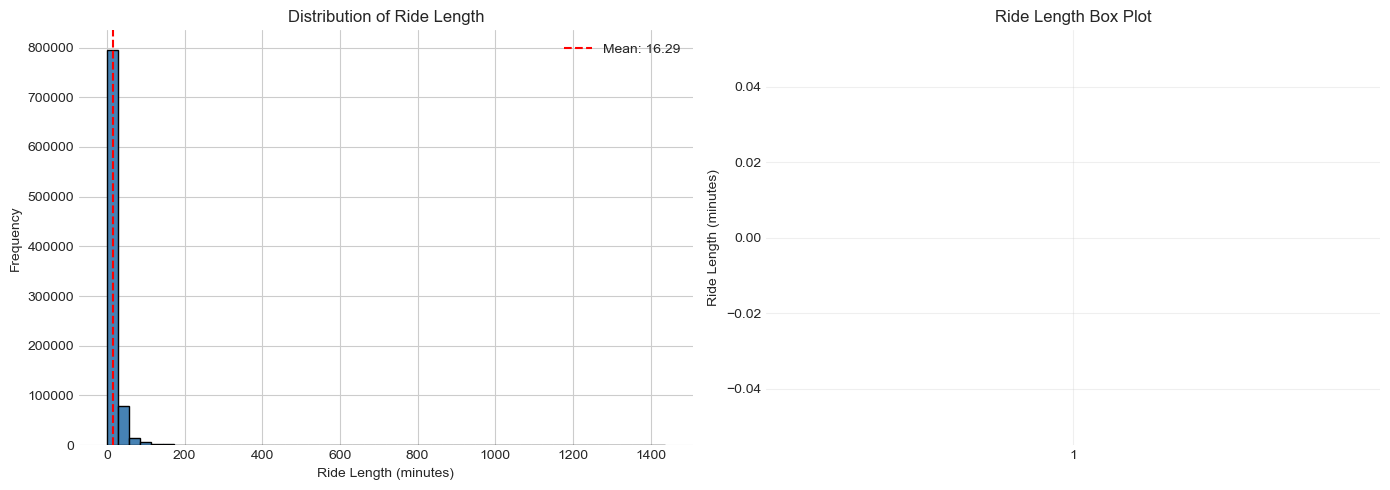

ValueError: invalid literal for int() with base 10: '10 AM'

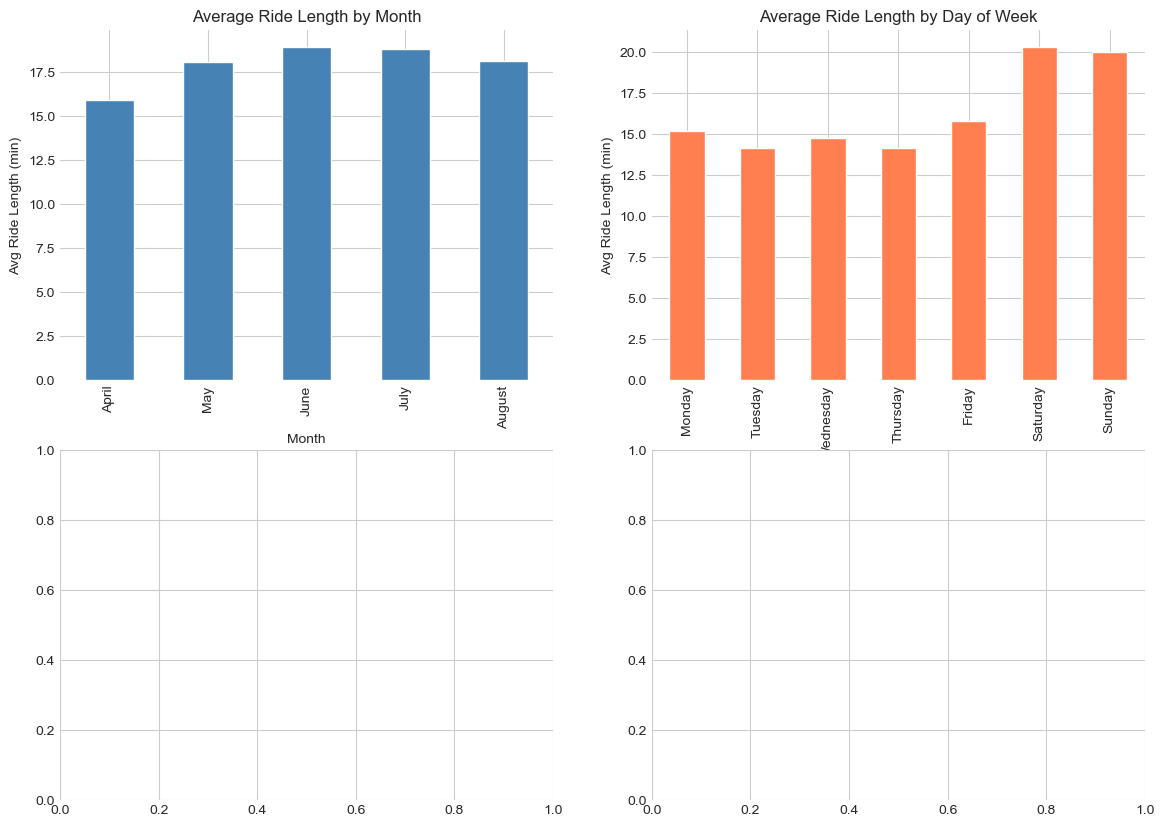

In [14]:
# Chicago Divvy Ride Length Prediction
# Two Model Comparison: Random Forest vs Gradient Boosting

# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
df = data.copy()

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cell 2: Load and Explore Data
print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df['ride_length'].describe())

# Cell 3: Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['ride_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Ride Length (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Ride Length')
axes[0].axvline(df['ride_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["ride_length"].mean():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['ride_length'])
axes[1].set_ylabel('Ride Length (minutes)')
axes[1].set_title('Ride Length Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cell 4: Exploratory Data Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ride length by month
month_order = ['April', 'May', 'June', 'July', 'August']
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)
df.groupby('month_name')['ride_length'].mean().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average Ride Length by Month')
axes[0, 0].set_ylabel('Avg Ride Length (min)')
axes[0, 0].set_xlabel('Month')

# Ride length by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)
df.groupby('day_of_week')['ride_length'].mean().sort_index().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Average Ride Length by Day of Week')
axes[0, 1].set_ylabel('Avg Ride Length (min)')
axes[0, 1].set_xlabel('Day of Week')

# Ride length by hour
# cobverting hour of day to integer
df['hour_of_day'] = df['hour_of_day'].astype(int)
hour_order = sorted(df['hour_of_day'].unique())
df.groupby('hour_of_day')['ride_length'].mean().reindex(hour_order).plot(kind='line', ax=axes[1, 0], marker='o', color='green')
axes[1, 0].set_title('Average Ride Length by Hour of Day')
axes[1, 0].set_ylabel('Avg Ride Length (min)')
axes[1, 0].set_xlabel('Hour of Day')

# Ride length by rideable type
df.groupby('rideable_type')['ride_length'].mean().plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Average Ride Length by Rideable Type')
axes[1, 1].set_ylabel('Avg Ride Length (min)')
axes[1, 1].set_xlabel('Rideable Type')

plt.tight_layout()
plt.show()

# Cell 5: Member vs Casual Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by membership type
df.boxplot(column='ride_length', by='member_casual', ax=axes[0])
axes[0].set_title('Ride Length Distribution by Member Type')
axes[0].set_xlabel('Member Type')
axes[0].set_ylabel('Ride Length (min)')

# Mean comparison
df.groupby('member_casual')['ride_length'].agg(['mean', 'median', 'std']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Ride Length Statistics by Member Type')
axes[1].set_ylabel('Value')
axes[1].legend(['Mean', 'Median', 'Std Dev'])

plt.tight_layout()
plt.show()

# Cell 6: Feature Engineering
df_model = df.copy()

# Extract hour as numeric
df_model['hour_numeric'] = df_model['hour_of_day'].str.extract('(\d+)').astype(int)

# Calculate distance using haversine formula
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lng1, lat2, lng2):
    R = 3959  # Earth's radius in miles
    lat1, lng1, lat2, lng2 = map(radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlng/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

df_model['distance_miles'] = df_model.apply(
    lambda row: haversine_distance(row['start_lat'], row['start_lng'], 
                                    row['end_lat'], row['end_lng']), axis=1
)

print("Distance Statistics:")
print(df_model['distance_miles'].describe())

# Encode categorical variables
le_month = LabelEncoder()
le_day = LabelEncoder()
le_rideable = LabelEncoder()
le_member = LabelEncoder()

df_model['month_encoded'] = le_month.fit_transform(df_model['month_name'])
df_model['day_encoded'] = le_day.fit_transform(df_model['day_of_week'])
df_model['rideable_encoded'] = le_rideable.fit_transform(df_model['rideable_type'])
df_model['member_encoded'] = le_member.fit_transform(df_model['member_casual'])

# Encode top 20 start and end stations (others as 'Other')
top_start = df_model['start_station_name'].value_counts().head(20).index
top_end = df_model['end_station_name'].value_counts().head(20).index

df_model['start_station'] = df_model['start_station_name'].apply(
    lambda x: x if x in top_start else 'Other'
)
df_model['end_station'] = df_model['end_station_name'].apply(
    lambda x: x if x in top_end else 'Other'
)

le_start = LabelEncoder()
le_end = LabelEncoder()
df_model['start_station_encoded'] = le_start.fit_transform(df_model['start_station'])
df_model['end_station_encoded'] = le_end.fit_transform(df_model['end_station'])

print("\nFeature Engineering Complete!")
print(f"Total features created: month, day, hour, distance, rideable_type, member_type, start_station, end_station")

# Cell 7: Prepare Data for Modeling
feature_cols = ['month_encoded', 'day_encoded', 'hour_numeric', 'rideable_encoded', 
                'member_encoded', 'start_station_encoded', 'end_station_encoded', 'distance_miles']

X = df_model[feature_cols]
y = df_model['ride_length']

# Check for missing values
print("Missing values in features:")
print(X.isnull().sum())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Cell 8: Model 1 - Random Forest Regressor
print("=" * 60)
print("MODEL 1: RANDOM FOREST REGRESSOR")
print("=" * 60)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, 
                                  random_state=42, n_jobs=-1, min_samples_split=5)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

print("\nRANDOM FOREST PERFORMANCE:")
print(f"Train MAE: {rf_train_mae:.4f} minutes")
print(f"Test MAE:  {rf_test_mae:.4f} minutes")
print(f"Train RMSE: {rf_train_rmse:.4f} minutes")
print(f"Test RMSE:  {rf_test_rmse:.4f} minutes")
print(f"Train R²: {rf_train_r2:.4f}")
print(f"Test R²:  {rf_test_r2:.4f}")

# Cell 9: Random Forest Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nRANDOM FOREST FEATURE IMPORTANCE:")
print(feature_importance_rf)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_rf['feature'], feature_importance_rf['importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest - Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Cell 10: Random Forest Residuals
residuals_rf = y_test - y_test_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual plot
axes[0].scatter(y_test_pred_rf, residuals_rf, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Ride Length (min)')
axes[0].set_ylabel('Residuals (min)')
axes[0].set_title('Random Forest - Residual Plot')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals_rf, bins=50, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Residuals (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Random Forest - Residual Distribution')
axes[1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

# Cell 11: Model 2 - Gradient Boosting Regressor
print("\n" + "=" * 60)
print("MODEL 2: GRADIENT BOOSTING REGRESSOR")
print("=" * 60)

gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, 
                                      max_depth=5, random_state=42, subsample=0.8)
gb_model.fit(X_train, y_train)

# Predictions
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

# Evaluation Metrics
gb_train_mae = mean_absolute_error(y_train, y_train_pred_gb)
gb_test_mae = mean_absolute_error(y_test, y_test_pred_gb)
gb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_gb))
gb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
gb_train_r2 = r2_score(y_train, y_train_pred_gb)
gb_test_r2 = r2_score(y_test, y_test_pred_gb)

print("\nGRADIENT BOOSTING PERFORMANCE:")
print(f"Train MAE: {gb_train_mae:.4f} minutes")
print(f"Test MAE:  {gb_test_mae:.4f} minutes")
print(f"Train RMSE: {gb_train_rmse:.4f} minutes")
print(f"Test RMSE:  {gb_test_rmse:.4f} minutes")
print(f"Train R²: {gb_train_r2:.4f}")
print(f"Test R²:  {gb_test_r2:.4f}")

# Cell 12: Gradient Boosting Feature Importance
feature_importance_gb = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nGRADIENT BOOSTING FEATURE IMPORTANCE:")
print(feature_importance_gb)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_gb['feature'], feature_importance_gb['importance'], color='coral')
ax.set_xlabel('Importance Score')
ax.set_title('Gradient Boosting - Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Cell 13: Gradient Boosting Residuals
residuals_gb = y_test - y_test_pred_gb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual plot
axes[0].scatter(y_test_pred_gb, residuals_gb, alpha=0.5, color='coral')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Ride Length (min)')
axes[0].set_ylabel('Residuals (min)')
axes[0].set_title('Gradient Boosting - Residual Plot')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals_gb, bins=50, color='coral', edgecolor='black')
axes[1].set_xlabel('Residuals (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Gradient Boosting - Residual Distribution')
axes[1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

# Cell 14: Model Comparison
comparison_df = pd.DataFrame({
    'Metric': ['Train MAE', 'Test MAE', 'Train RMSE', 'Test RMSE', 'Train R²', 'Test R²'],
    'Random Forest': [rf_train_mae, rf_test_mae, rf_train_rmse, rf_test_rmse, rf_train_r2, rf_test_r2],
    'Gradient Boosting': [gb_train_mae, gb_test_mae, gb_train_rmse, gb_test_rmse, gb_train_r2, gb_test_r2]
})

print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Cell 15: Comparison Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MAE Comparison
metrics = ['Train MAE', 'Test MAE']
rf_mae = [rf_train_mae, rf_test_mae]
gb_mae = [gb_train_mae, gb_test_mae]
x = np.arange(len(metrics))
width = 0.35
axes[0, 0].bar(x - width/2, rf_mae, width, label='Random Forest', color='steelblue')
axes[0, 0].bar(x + width/2, gb_mae, width, label='Gradient Boosting', color='coral')
axes[0, 0].set_ylabel('MAE (minutes)')
axes[0, 0].set_title('MAE Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()

# RMSE Comparison
metrics = ['Train RMSE', 'Test RMSE']
rf_rmse = [rf_train_rmse, rf_test_rmse]
gb_rmse = [gb_train_rmse, gb_test_rmse]
x = np.arange(len(metrics))
axes[0, 1].bar(x - width/2, rf_rmse, width, label='Random Forest', color='steelblue')
axes[0, 1].bar(x + width/2, gb_rmse, width, label='Gradient Boosting', color='coral')
axes[0, 1].set_ylabel('RMSE (minutes)')
axes[0, 1].set_title('RMSE Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics)
axes[0, 1].legend()

# R² Comparison
metrics = ['Train R²', 'Test R²']
rf_r2 = [rf_train_r2, rf_test_r2]
gb_r2 = [gb_train_r2, gb_test_r2]
x = np.arange(len(metrics))
axes[1, 0].bar(x - width/2, rf_r2, width, label='Random Forest', color='steelblue')
axes[1, 0].bar(x + width/2, gb_r2, width, label='Gradient Boosting', color='coral')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('R² Score Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].legend()

# Actual vs Predicted for both models
axes[1, 1].scatter(y_test, y_test_pred_rf, alpha=0.4, label='Random Forest', color='steelblue', s=20)
axes[1, 1].scatter(y_test, y_test_pred_gb, alpha=0.4, label='Gradient Boosting', color='coral', s=20)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Ride Length (min)')
axes[1, 1].set_ylabel('Predicted Ride Length (min)')
axes[1, 1].set_title('Actual vs Predicted - Both Models')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Cell 16: Key Insights and Recommendations
print("\n" + "=" * 80)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

better_model = "Gradient Boosting" if gb_test_r2 > rf_test_r2 else "Random Forest"
print(f"\n1. BEST MODEL: {better_model}")
print(f"   - Achieves R² score of {max(gb_test_r2, rf_test_r2):.4f} on test data")
print(f"   - Test MAE: {min(gb_test_mae, rf_test_mae):.4f} minutes")

print(f"\n2. TOP 3 MOST IMPORTANT FEATURES:")
top_features = feature_importance_gb.head(3) if gb_test_r2 > rf_test_r2 else feature_importance_rf.head(3)
for idx, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"   {idx}. {row['feature']}: {row['importance']:.4f}")

print(f"\n3. MODEL CHARACTERISTICS:")
print(f"   - Distance traveled is a strong predictor of ride length")
print(f"   - Member type and time-of-day factors influence ride behavior")
print(f"   - Station location (especially start station) impacts predictions")

print(f"\n4. RESIDUAL ANALYSIS:")
print(f"   - Random Forest Test Residual Mean: {residuals_rf.mean():.4f}")
print(f"   - Gradient Boosting Test Residual Mean: {residuals_gb.mean():.4f}")
print(f"   - Suggests models have minimal bias in predictions")